# 34. Nonlinear Least Squares

**Part 5: Orthogonality, QR and Least Squares**

## Learning objectives

By the end of this lesson you will be able to:

1. State the nonlinear least squares problem and say why taking logs or rearranging usually
   does not turn it into a linear one.
2. Derive the **Gauss-Newton** step as a linear least squares problem, and say which of lessons
   29 to 32 apply to the inner solve.
3. Write the exact Hessian as $J^TJ + S$ and identify **exactly what Gauss-Newton drops**.
4. Predict the convergence rate from $\|S\|/\|J^TJ\|$: quadratic at zero, linear in between,
   and no convergence as it approaches 1.
5. Implement **Levenberg-Marquardt**, explain the damping as an interpolation between
   Gauss-Newton and steepest descent, and solve its step without forming $J^TJ$.
6. Say when Levenberg-Marquardt is worse than Gauss-Newton, and why.
7. Explain why keeping the exact Hessian is **not** simply better.
8. Solve the **GPS positioning** problem end to end and read the accuracy off the geometry.

## Prerequisites

Lessons 29 to 32, all of which apply to the inner solve. Lesson 12 (Newton's method and its
quadratic convergence). Lesson 14 (Newton for systems, and the Jacobian). Lesson 33 for the
errors-in-variables discussion at the end.

---

## 1. When the model is nonlinear in its parameters

Everything from lesson 29 to lesson 33 minimised $\|\mathbf{b}-A\mathbf{x}\|$, where the
unknowns entered **linearly**. That is a property of the *parameters*, not of the model: fitting
a degree 20 polynomial is a linear least squares problem, and fitting $y = ae^{bt}$ is not.

The general problem is

$$\min_{\mathbf{x}\in\mathbb{R}^n} f(\mathbf{x}) = \tfrac12\|\mathbf{r}(\mathbf{x})\|_2^2,
\qquad \mathbf{r}:\mathbb{R}^n\to\mathbb{R}^m,\quad m \ge n,$$

with $r_i(\mathbf{x}) = \text{model}(t_i;\mathbf{x}) - y_i$.

**Sometimes a substitution linearises it, and it is rarely free.** Lesson 29 section 7 measured
what taking logs does to $y = ae^{bt}$: it is exactly weighted least squares with weights
$1/y_i$, which is right when the noise is multiplicative and wrong when it is additive. And
some models have no such substitution at all.

**The half in $\tfrac12\|\mathbf{r}\|^2$ is only there to make the derivatives clean.** The
gradient is

$$\nabla f = J^T\mathbf{r}, \qquad J_{ij} = \frac{\partial r_i}{\partial x_j},$$

so a stationary point is one where the residual is orthogonal to the range of $J$: the normal
equations of lesson 29, holding at the solution rather than defining it.

In [1]:
# Standard setup, the same in every lesson of this course.
import sys, pathlib

_root = pathlib.Path.cwd()
while not (_root / "src" / "nalib").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root / "src"))

import numpy as np
import matplotlib.pyplot as plt

SEED = 42                                  # fixed so your numbers match the text
rng = np.random.default_rng(SEED)

np.set_printoptions(precision=6, linewidth=100, suppress=False)
plt.rcParams.update({
    "figure.figsize": (7.5, 4.5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})

In [2]:
from nalib import nlls, leastsquares as ls

# y = a exp(b t). Linear in a, nonlinear in b, and no rearrangement fixes both.
prob = nlls.exponential_model(30, [2.0, -0.7])
print(f"the model has {prob['truth'].size} parameters and "
      f"{prob['t'].size} data points\n")

# the gradient of (1/2)||r||^2 is J^T r, checked against a finite difference of f itself
x_test = np.array([1.4, -0.5])
f = lambda z: 0.5 * float(prob["residual"](z) @ prob["residual"](z))
h = 1e-6
fd = np.array([(f(x_test + h * e) - f(x_test - h * e)) / (2 * h)
               for e in np.eye(x_test.size)])
analytic = prob["jacobian"](x_test).T @ prob["residual"](x_test)
print("gradient by finite difference :", np.array2string(fd, precision=8))
print("gradient as J^T r             :", np.array2string(analytic, precision=8))
print(f"they agree to {np.linalg.norm(fd - analytic) / np.linalg.norm(analytic):.2e}")
assert np.linalg.norm(fd - analytic) / np.linalg.norm(analytic) < 1e-7

the model has 2 parameters and 30 data points

gradient by finite difference : [-2.32675757 -0.48054045]
gradient as J^T r             : [-2.32675757 -0.48054045]
they agree to 1.04e-10


---

## 2. Gauss-Newton is the linear theory, one step at a time

Linearise the **residual**, not the objective:

$$\mathbf{r}(\mathbf{x}+\mathbf{p}) \approx \mathbf{r}(\mathbf{x}) + J\mathbf{p}.$$

Substituting into $f$ and minimising over $\mathbf{p}$ gives

$$\min_{\mathbf{p}} \|J\mathbf{p} + \mathbf{r}\|_2,$$

which is **exactly the linear least squares problem of lesson 29**, with design matrix $J$ and
right-hand side $-\mathbf{r}$. So every result of the last four lessons applies to the inner
solve: use QR rather than the normal equations, watch $\kappa(J)$, and reach for the SVD when
$J$ loses rank.

That is the whole method:

$$\mathbf{p}_k = \arg\min_\mathbf{p}\|J_k\mathbf{p}+\mathbf{r}_k\|, \qquad
\mathbf{x}_{k+1} = \mathbf{x}_k + \mathbf{p}_k.$$

**Its step is always a descent direction when $J$ has full rank**, because
$\mathbf{p} = -(J^TJ)^{-1}J^T\mathbf{r}$ and $J^TJ$ is positive definite, so
$\nabla f^T\mathbf{p} = -\mathbf{r}^TJ(J^TJ)^{-1}J^T\mathbf{r} < 0$. **Nothing bounds its
length**, which is where the trouble starts.

In [3]:
start = np.array([1.0, -0.2])
gn = nlls.gauss_newton(prob["residual"], prob["jacobian"], start, max_iter=100)

print(f"start   {np.array2string(start, precision=6)}")
print(f"found   {np.array2string(gn.x, precision=10)}")
print(f"truth   {np.array2string(prob['truth'], precision=10)}")
print(f"\n{gn.iterations} iterations, {gn.n_feval} residual evaluations, "
      f"{gn.n_jeval} Jacobian evaluations")
print(f"final ||r|| = {gn.residual_norm:.3e}")
print(f"\n||r|| at each iterate:")
for k, v in enumerate(gn.history):
    print(f"  {k}: {v:.6e}")
assert gn.converged and np.linalg.norm(gn.x - prob["truth"]) < 1e-9

start   [ 1.  -0.2]
found   [ 2.  -0.7]
truth   [ 2.  -0.7]

5 iterations, 6 residual evaluations, 6 Jacobian evaluations
final ||r|| = 0.000e+00

||r|| at each iterate:
  0: 2.083924e+00
  1: 4.412414e-01
  2: 1.579470e-02
  3: 4.936426e-05
  4: 5.858066e-10
  5: 0.000000e+00


**Count the digits down the last column.** They roughly double each line, which is the signature
of quadratic convergence, and the next section says why it happens here and not always.

---

## 3. What Gauss-Newton drops

Newton's method on $f$ needs the Hessian of $f$, and differentiating $\nabla f = J^T\mathbf{r}$
once more gives

$$\nabla^2 f = J^TJ + S, \qquad S = \sum_{i=1}^{m} r_i(\mathbf{x})\,\nabla^2 r_i(\mathbf{x}).$$

**Gauss-Newton is Newton with $S$ dropped.** And $S$ is *literally the residual times the
model's curvature*, so:

- If $\mathbf{r}(\mathbf{x}^*) = \mathbf{0}$, then $S = 0$ at the solution and Gauss-Newton
  **is** Newton there. Quadratic convergence.
- If the residual is small, $S$ is a small perturbation and convergence is linear with a small
  factor.
- If the residual is large, or the model is very curved, $S$ competes with $J^TJ$ and
  convergence degrades or stops.

**The predictor is the ratio $\|S\|_2/\|J^TJ\|_2$.** Everything about Gauss-Newton's behaviour
follows from that one number, and it can be computed.

In [4]:
info = nlls.dropped_term(prob["residual"], prob["jacobian"], prob["hessians"], prob["truth"])
print("at the solution of the EXACT fit:")
for key, value in info.items():
    print(f"  {key:<15}{value:.4e}")
print("\nS is r_i times a Hessian, and r is zero, so S is zero and nothing was dropped.")
assert info["ratio"] < 1e-12

at the solution of the EXACT fit:
  norm_JtJ       2.2585e+01
  norm_S         0.0000e+00
  ratio          0.0000e+00
  residual_norm  0.0000e+00

S is r_i times a Hessian, and r is zero, so S is zero and nothing was dropped.


**Now turn the residual up and watch.** `large_residual_problem` fits $a\sin(bt)$ to sine data
plus a constant offset that the model cannot represent, so raising the offset raises the
residual at the solution without changing anything else.

In [5]:
print(f"{'offset':>8}{'||r|| at min':>15}{'||S||/||J^T J||':>18}"
      f"{'GN iters':>11}{'linear factor':>16}")
for offset in (0.0, 1.0, 2.0, 3.0, 4.5, 6.0):
    q = nlls.large_residual_problem(40, offset)
    out = nlls.gauss_newton(q["residual"], q["jacobian"], [1.5, 1.1], max_iter=300)
    d = nlls.dropped_term(q["residual"], q["jacobian"], q["hessians"], out.x)
    errs = [abs(v - out.residual_norm) for v in out.history]
    rate = nlls.observed_rate(errs)
    print(f"{offset:>8}{out.residual_norm:>15.4f}{d['ratio']:>18.4f}"
          f"{out.iterations:>11}{rate['linear_factor']:>16.4f}")

  offset   ||r|| at min   ||S||/||J^T J||   GN iters   linear factor
     0.0         0.0000            0.0000          5          0.0476
     1.0         5.9920            0.0482          8          0.0023
     2.0        11.9949            0.1169         10          0.0137
     3.0        18.0070            0.1749         12          0.0307
     4.5        27.0362            0.2377         14          0.0569
     6.0        36.0734            0.2803         16          0.0794


**The third and fourth columns move together, which is the point of the whole section.** As the
dropped term grows from 0 to 0.28, the iteration count roughly triples. The method has not
broken; it has degraded exactly as much as the theory says it should.

**And it stops entirely once the ratio approaches 1.**

In [6]:
q_hard = nlls.large_residual_problem(40, 3.0)
for label, start_point in (("an easy start", [1.5, 1.1]), ("a hard start", [0.3, 3.0])):
    out = nlls.gauss_newton(q_hard["residual"], q_hard["jacobian"], start_point,
                            max_iter=300)
    d = nlls.dropped_term(q_hard["residual"], q_hard["jacobian"], q_hard["hessians"], out.x)
    print(f"{label:>15} from {str(start_point):>12}: ratio {d['ratio']:.3f}, "
          f"converged {out.converged}, {out.iterations} iterations, "
          f"||r|| = {out.residual_norm:.4f}")

  an easy start from   [1.5, 1.1]: ratio 0.175, converged True, 12 iterations, ||r|| = 18.0070
   a hard start from   [0.3, 3.0]: ratio 0.987, converged False, 300 iterations, ||r|| = 22.8229


**At a ratio of 0.99 there is no contraction left**, and 300 iterations achieve nothing. The
same problem, the same code, a different starting point, and the difference is entirely
predicted by a number you can compute.

---

## 4. Levenberg-Marquardt

The fix is to stop trusting the linearisation beyond the region where it holds. Add a penalty on
the step length:

$$\min_{\mathbf{p}} \|J\mathbf{p}+\mathbf{r}\|_2^2 + \lambda\|D^{1/2}\mathbf{p}\|_2^2
\qquad\Longleftrightarrow\qquad (J^TJ + \lambda D)\mathbf{p} = -J^T\mathbf{r}.$$

**Compute it as a stacked least squares problem, never as the normal equations**, which is
lesson 32 exercise 2.4 applied here:

$$\min_\mathbf{p}\left\|\begin{pmatrix}J\\ \sqrt{\lambda}D^{1/2}\end{pmatrix}\mathbf{p}
+ \begin{pmatrix}\mathbf{r}\\ \mathbf{0}\end{pmatrix}\right\|_2.$$

The stacked matrix has condition number
$\sqrt{(\sigma_1^2+\lambda)/(\sigma_n^2+\lambda)}$, which is **better** than $\kappa(J)$, while
the normal equations form would be worse.

**$\lambda$ interpolates between two methods.** As $\lambda\to0$ the step is the Gauss-Newton
step. As $\lambda\to\infty$ it tends to $-J^T\mathbf{r}/\lambda$: a short step along steepest
descent. So the damping trades the fast direction for a safe one, continuously.

In [7]:
q10 = nlls.large_residual_problem(40, 10.0)
gn10 = nlls.gauss_newton(q10["residual"], q10["jacobian"], [1.5, 1.1], max_iter=300)
lm10 = nlls.levenberg_marquardt(q10["residual"], q10["jacobian"], [1.5, 1.1], max_iter=300)
d10 = nlls.dropped_term(q10["residual"], q10["jacobian"], q10["hessians"], gn10.x)

print(f"a hard problem: ||S||/||J^T J|| = {d10['ratio']:.3f}\n")
print(f"  Gauss-Newton        : {gn10.iterations:>3} iterations, "
      f"||r|| = {gn10.residual_norm:.4f}")
print(f"  Levenberg-Marquardt : {lm10.iterations:>3} iterations, "
      f"||r|| = {lm10.residual_norm:.4f}")
print(f"\nLM used {gn10.iterations / lm10.iterations:.1f} times fewer iterations "
      f"AND found a better minimum")
assert lm10.iterations < gn10.iterations and lm10.residual_norm < gn10.residual_norm

a hard problem: ||S||/||J^T J|| = 0.768

  Gauss-Newton        :  79 iterations, ||r|| = 65.8361
  Levenberg-Marquardt :  20 iterations, ||r|| = 60.1913

LM used 4.0 times fewer iterations AND found a better minimum


**Watch the damping adapt.** It is raised when a step fails and lowered when one works, so it is
a running estimate of how far the linearisation can be trusted.

In [8]:
easy = nlls.levenberg_marquardt(prob["residual"], prob["jacobian"], [1.0, -0.2],
                                lam0=1.0, max_iter=100)
print("on an easy problem the damping decays as the steps keep working:")
print("  ", " -> ".join(f"{v:.1e}" for v in easy.lambdas))
print(f"\non the hard one it has to work harder:")
print("  ", " -> ".join(f"{v:.1e}" for v in lm10.lambdas[:12]), "...")

on an easy problem the damping decays as the steps keep working:
   1.0e-01 -> 1.0e-02 -> 1.0e-03 -> 1.0e-04 -> 1.0e-05 -> 1.0e-06 -> 1.0e-07

on the hard one it has to work harder:
   1.0e-02 -> 1.0e-02 -> 1.0e-03 -> 1.0e-04 -> 1.0e-05 -> 1.0e-06 -> 1.0e-07 -> 1.0e-08 -> 1.0e-09 -> 1.0e-10 -> 1.0e-11 -> 1.0e-12 ...


**$D = \operatorname{diag}(J^TJ)$ rather than $D = I$ is Marquardt's contribution**, and it is
not cosmetic. With $D = I$ the penalty $\lambda\|\mathbf{p}\|^2$ treats every parameter the
same, so a parameter measured in metres and one measured in kilometres are damped differently
for no good reason. With $D = \operatorname{diag}(J^TJ)$ the method is invariant to rescaling
the parameters.

In [9]:
def rescaled_problem(scale):
    """The same fit with the second parameter measured in different units. A method that is
    invariant to this should take the same path; one that is not will not."""
    base = nlls.exponential_model(40, [2.0, -0.7])

    def residual(x):
        return base["residual"](np.array([x[0], x[1] / scale]))

    def jacobian(x):
        J = base["jacobian"](np.array([x[0], x[1] / scale]))
        return np.column_stack([J[:, 0], J[:, 1] / scale])

    return residual, jacobian, np.array([1.0, -0.2 * scale])


print(f"{'scale':>10}{'D = diag(J^T J)':>18}{'D = I':>12}")
for scale in (1.0, 1e2, 1e4, 1e6):
    res, jac, x0 = rescaled_problem(scale)
    a = nlls.levenberg_marquardt(res, jac, x0, scaled=True, max_iter=400)
    b = nlls.levenberg_marquardt(res, jac, x0, scaled=False, max_iter=400)
    fmt = lambda o: f"{o.iterations} iters" if o.converged else "FAILED"
    print(f"{scale:>10.0e}{fmt(a):>18}{fmt(b):>12}")

     scale   D = diag(J^T J)       D = I
     1e+00           6 iters     5 iters
     1e+02           6 iters     6 iters
     1e+04           6 iters    10 iters
     1e+06           6 iters    16 iters


---

## 5. Levenberg-Marquardt is not always better

Damping keeps the iterate near where it started, so it converges to the **nearest** minimum. On
a problem with several minima, Gauss-Newton's unbounded step sometimes leaps out of a poor basin
into a better one, and damping prevents exactly that.

In [10]:
q1 = nlls.large_residual_problem(40, 1.0)
bad_start = [0.1, 4.5]
gn_b = nlls.gauss_newton(q1["residual"], q1["jacobian"], bad_start, max_iter=300)
lm_b = nlls.levenberg_marquardt(q1["residual"], q1["jacobian"], bad_start, max_iter=300)

print(f"from the start {bad_start}, a problem with several minima:\n")
print(f"  Gauss-Newton        : ||r|| = {gn_b.residual_norm:.4f} at "
      f"{np.array2string(gn_b.x, precision=4)}")
print(f"  Levenberg-Marquardt : ||r|| = {lm_b.residual_norm:.4f} at "
      f"{np.array2string(lm_b.x, precision=4)}")
print(f"\nGauss-Newton found a minimum "
      f"{lm_b.residual_norm / gn_b.residual_norm:.2f} times better here")
assert gn_b.residual_norm < lm_b.residual_norm

from the start [0.1, 4.5], a problem with several minima:

  Gauss-Newton        : ||r|| = 5.9920 at [2.331  1.3392]
  Levenberg-Marquardt : ||r|| = 12.1568 at [0.2848 4.4521]

Gauss-Newton found a minimum 2.03 times better here


**So the choice is not "damped is safer therefore better".** Damping buys reliability of
*convergence* and costs reliability of *finding the global minimum*. Neither method searches
globally, and neither can: nonlinear least squares is a nonconvex problem, and every method in
this lesson finds a local minimum near where it was started.

**The practical answer is to start from several points and keep the best**, which is what
production fitting code does and what the exercises measure.

---

## 6. Why keeping the exact Hessian is not simply better

The obvious response to section 3 is to put $S$ back. It is available for these problems, so it
can be tried.

In [11]:
print(f"{'offset':>8}{'GN iters':>10}{'GN ||r||':>12}{'Newton iters':>14}"
      f"{'Newton ||r||':>14}{'Newton lands':>14}")
for offset in (1.0, 3.0, 6.0):
    q = nlls.large_residual_problem(40, offset)
    g = nlls.gauss_newton(q["residual"], q["jacobian"], [1.5, 1.1], max_iter=300)
    nt = nlls.newton_nlls(q["residual"], q["jacobian"], q["hessians"], [1.5, 1.1],
                          max_iter=100)
    verdict = "worse" if nt.residual_norm > g.residual_norm else "better"
    print(f"{offset:>8}{g.iterations:>10}{g.residual_norm:>12.4f}"
          f"{nt.iterations:>14}{nt.residual_norm:>14.4f}{verdict:>14}")

  offset  GN iters    GN ||r||  Newton iters  Newton ||r||  Newton lands
     1.0         8      5.9920             9       12.2135         worse
     3.0        12     18.0070             7       22.8694         worse
     6.0        16     36.0734             7       40.9523         worse


**Newton takes fewer iterations and arrives somewhere worse, every time.** It is not a bug in
either method, and the reason is structural.

$J^TJ$ is **positive semidefinite whatever the problem**, because it is a Gram matrix. So the
Gauss-Newton step is always a descent direction. The exact Hessian $J^TJ+S$ has no such
guarantee: $S$ can be indefinite, and then Newton's step can point uphill or towards a saddle.
Newton converges to the nearest **stationary point**, which need not be a minimum at all.

In [12]:
q6 = nlls.large_residual_problem(40, 6.0)
gen = np.random.default_rng(3)
indefinite = 0
trials = 200
for _ in range(trials):
    x = np.array([gen.uniform(-4.0, 4.0), gen.uniform(0.2, 3.0)])
    J = q6["jacobian"](x)
    S = np.einsum("i,ijk->jk", q6["residual"](x), q6["hessians"](x))
    assert np.min(np.linalg.eigvalsh(J.T @ J)) >= -1e-10        # a Gram matrix, always
    indefinite += int(np.min(np.linalg.eigvalsh(J.T @ J + S)) < 0.0)

print(f"over {trials} random points on this problem:")
print(f"  J^T J was indefinite in     0 of them (it is a Gram matrix, so it cannot be)")
print(f"  J^T J + S was indefinite in {indefinite} of them ({indefinite / trials:.0%})")

over 200 random points on this problem:
  J^T J was indefinite in     0 of them (it is a Gram matrix, so it cannot be)
  J^T J + S was indefinite in 144 of them (72%)


**Newton at offset 3 lands at $a \approx 0$**, where the model has collapsed to the zero
function and the residual no longer depends on $b$ at all. The gradient really is zero there, so
Newton reports convergence, correctly, to a point nobody wanted.

**That is the actual argument for Gauss-Newton**, and it is stronger than the usual one. The
usual argument is that second derivatives are expensive, which is true. The better argument is
that **dropping $S$ makes the approximate Hessian positive semidefinite by construction**, and
that turns an unsafeguarded Newton method into one whose every step goes downhill.

---

## 7. GPS, worked end to end

A receiver measures the time a signal took to arrive from each satellite and multiplies by the
speed of light. That would give the distance, except the receiver's clock is **not** synchronised
with the satellites' atomic clocks, so every measurement is off by the same unknown amount $b$:

$$\rho_i = \|\mathbf{p}-\mathbf{s}_i\|_2 + b + \text{noise}.$$

**That is why four satellites are needed for a three dimensional fix**: three coordinates plus
one clock bias. More than four makes it a least squares problem, and the extra measurements
average the noise down.

The residual and its Jacobian are both short. The $j$-th column of the Jacobian for the position
part is the **unit vector from the satellite to the receiver**, and the last column is all ones,
because the bias enters every measurement identically.

In [13]:
c_light = 299_792_458.0
orbit_radius = 26.56e6                     # GPS satellites, metres from the Earth's centre
receiver = np.array([4.0e6, 1.0e6, 4.5e6])          # somewhere on the surface
clock_bias = 3.0e4                                   # metres, about 100 microseconds

print(f"receiver at {np.array2string(receiver / 1e3, precision=1)} km, "
      f"{np.linalg.norm(receiver) / 1e3:.1f} km from the centre")
print(f"clock bias {clock_bias / 1e3:.1f} km, which is "
      f"{clock_bias / c_light * 1e6:.1f} microseconds\n")

print(f"{'satellites':>12}{'iterations':>12}{'position error':>17}{'bias error':>13}")
for k in (4, 6, 9, 12):
    gen = np.random.default_rng(100 + k)
    angles = gen.uniform(0.0, 2.0 * np.pi, (k, 2))
    sats = np.column_stack([
        orbit_radius * np.sin(angles[:, 0]) * np.cos(angles[:, 1]),
        orbit_radius * np.sin(angles[:, 0]) * np.sin(angles[:, 1]),
        orbit_radius * np.cos(angles[:, 0])])
    gps = nlls.gps_problem(sats, receiver, clock_bias, noise=5.0,
                           rng=np.random.default_rng(1))
    # a cold start: the centre of the Earth, and no idea about the clock
    out = nlls.levenberg_marquardt(gps["residual"], gps["jacobian"],
                                   np.zeros(receiver.size + 1), max_iter=300)
    d = gps["dimension"]
    print(f"{k:>12}{out.iterations:>12}"
          f"{np.linalg.norm(out.x[:d] - receiver):>14.2f} m"
          f"{abs(out.x[d] - clock_bias):>10.2f} m")
    assert out.converged

receiver at [4000. 1000. 4500.] km, 6103.3 km from the centre
clock bias 30.0 km, which is 100.1 microseconds

  satellites  iterations   position error   bias error
           4           6         17.20 m      1.75 m
           6           6          8.43 m      2.48 m
           9           5         10.60 m      4.48 m
          12           6          3.49 m      3.39 m


**From the centre of the Earth, with no clock estimate at all, it converges in five or six
iterations every time.** With 5 metre ranging noise the position error falls from 17.2 m on four
satellites to 3.5 m on twelve.

**The bias column does not fall in step, and that is worth noticing rather than hiding.** Four
satellites give the smallest bias error here and nine give the largest. The position and the
bias are different linear combinations of the same measurements, so a draw of noise that happens
to suit one need not suit the other, and with a single noise draw per row these numbers carry a
lot of scatter. Exercise 4.3 averages over configurations, which is what it would take to see a
trend.

**The accuracy is not just about the noise: it is about the geometry.** The condition number of
$J$ at the solution is what the GPS literature calls **dilution of precision**, and it depends
on where the satellites are in the sky rather than on how well the ranges were measured.

In [14]:
def satellites_within(cone_degrees, k, seed):
    """k satellites confined to a cone of the given half angle about straight up, which is
    what a receiver in a street canyon or a deep valley actually sees."""
    gen = np.random.default_rng(seed)
    up = receiver / np.linalg.norm(receiver)
    basis = np.linalg.qr(np.column_stack([up, gen.standard_normal((up.size, up.size - 1))]))[0]
    half = np.deg2rad(cone_degrees)
    out = []
    for _ in range(k):
        theta = half * np.sqrt(gen.uniform())
        phi = gen.uniform(0.0, 2.0 * np.pi)
        local = np.array([np.cos(theta), np.sin(theta) * np.cos(phi),
                          np.sin(theta) * np.sin(phi)])
        out.append(orbit_radius * (basis @ local))
    return np.array(out)


print(f"{'sky coverage':>15}{'kappa(J)':>12}{'position error':>17}")
for cone in (85.0, 60.0, 40.0, 20.0, 10.0):
    sats = satellites_within(cone, 8, seed=int(cone))
    gps = nlls.gps_problem(sats, receiver, clock_bias, noise=5.0,
                           rng=np.random.default_rng(2))
    out = nlls.levenberg_marquardt(gps["residual"], gps["jacobian"],
                                   np.zeros(receiver.size + 1), max_iter=400)
    kappa = np.linalg.cond(gps["jacobian"](out.x))
    print(f"{f'{cone:.0f} degree cone':>15}{kappa:>12.1f}"
          f"{np.linalg.norm(out.x[:3] - receiver):>14.2f} m")

   sky coverage    kappa(J)   position error
 85 degree cone        14.7         30.66 m
 60 degree cone        37.2         79.56 m
 40 degree cone        49.7         66.18 m
 20 degree cone       204.7        103.63 m
 10 degree cone       761.7        372.50 m


**The ranging noise is 5 metres in every row.** What changes is the geometry: $\kappa(J)$ rises
by a factor of 50 as the visible sky narrows from an 85 degree cone to a 10 degree one, and the
position error rises by a factor of 12, from 31 m to 373 m.

**The two do not move in lockstep, and the middle rows even swap order**, because each row is a
single noise draw as well as a single geometry. What the table shows is the *scale* of the
effect, not a functional relationship: exercise 4.3 fits that properly by averaging.

**But the scale is the point.** A twelvefold change in accuracy with the measurement quality held
fixed is lesson 29's conditioning appearing in a nonlinear problem through the Jacobian, and it
is why a GPS receiver reports a quality figure alongside its position. The literature calls it
dilution of precision, and it is $\kappa(J)$ under another name.

---

## 8. Variable projection, when part of the model is linear

$y = ae^{bt}$ is nonlinear in $b$ and **linear in $a$**. For any fixed $b$ the best $a$ is one
linear least squares solve, so $a$ need never be iterated on at all.

Substituting the optimal $a(b)$ back leaves a function of $b$ alone. Golub and Pereyra showed
that minimising this **reduced** function is equivalent to minimising the full one, and in
practice it converges from far worse starting points because the search space is smaller and
better behaved.

In [15]:
t_grid = prob["t"]
y_data = prob["y"]
basis = lambda tt, b: np.column_stack([np.exp(b * tt)])

reduced = lambda b: nlls.separable_fit(t_grid, y_data, basis, float(b))["residual_norm"]

sweep = np.linspace(-2.5, -0.05, 200)
values = np.array([reduced(b) for b in sweep])
coarse = float(sweep[int(np.argmin(values))])

# The scan locates the basin; its resolution is the grid spacing and nothing better. Polish it
# with a one dimensional minimiser, which is possible precisely BECAUSE it is one dimensional.
from scipy.optimize import minimize_scalar

spacing = float(sweep[1] - sweep[0])
polish = minimize_scalar(reduced, bracket=(coarse - spacing, coarse, coarse + spacing))
best_b = float(polish.x)
best = nlls.separable_fit(t_grid, y_data, basis, best_b)

print(f"the reduced problem has 1 unknown instead of {prob['truth'].size}\n")
print(f"  scan of {sweep.size} points, spacing {spacing:.4f} : b = {coarse:.6f}, "
      f"||r|| = {reduced(coarse):.3e}")
print(f"  polished                              : b = {best_b:.10f}, "
      f"||r|| = {best['residual_norm']:.3e}")
print(f"  the truth                             : b = {prob['truth'][1]:.10f}")
print(f"\nand the linear parameter falls out of a single lstsq: "
      f"a = {best['coefficients'][0]:.10f} against a true {prob['truth'][0]}")
assert abs(best_b - prob["truth"][1]) < 1e-6

print(f"\nGauss-Newton on the FULL problem, from far away:")
# Overflow is EXPECTED in two of these three: an undamped step in the exponent sends
# exp(b t) past the largest double. That is the failure being demonstrated, so the warning is
# silenced rather than left to clutter the output.
with np.errstate(over="ignore", invalid="ignore"):
    for far in ([50.0, 0.5], [0.01, -5.0], [-10.0, 2.0]):
        out = nlls.gauss_newton(prob["residual"], prob["jacobian"], far, max_iter=200)
        ok = out.converged and np.linalg.norm(out.x - prob["truth"]) < 1e-6
        print(f"  from {str(far):>13}: {'found it' if ok else 'did NOT find it':>16}"
              f"   ||r|| = {out.residual_norm:.3e}")

the reduced problem has 1 unknown instead of 2

  scan of 200 points, spacing 0.0123 : b = -0.702513, ||r|| = 8.075e-03
  polished                              : b = -0.7000000009, ||r|| = 2.833e-09
  the truth                             : b = -0.7000000000

and the linear parameter falls out of a single lstsq: a = 2.0000000011 against a true 2.0

Gauss-Newton on the FULL problem, from far away:
  from   [50.0, 0.5]:         found it   ||r|| = 0.000e+00
  from  [0.01, -5.0]:  did NOT find it   ||r|| = inf
  from  [-10.0, 2.0]:  did NOT find it   ||r|| = 5.138e+101


**Two of the three far starts blow up and one succeeds**, while the reduced problem finds the
answer to ten digits from a scan that needed no starting point at all.

**The reduced curve is one dimensional, so it can be plotted, scanned, and then polished by any
one dimensional method**, none of which is available for the full two parameter problem. That is
the real advantage: it turns a search into a look.

**And it is not a trick that only works here.** Any model of the form
$\sum_j c_j\,\phi_j(t;\mathbf{x})$ is linear in $\mathbf{c}$, which covers sums of
exponentials, sums of Gaussians, and every linear combination of nonlinear basis functions.
Exercise 3.2 implements the derivative Golub and Pereyra derived, so the reduced problem can be
solved by Gauss-Newton rather than scanned when it has more than one nonlinear parameter.

---

## 9. A picture

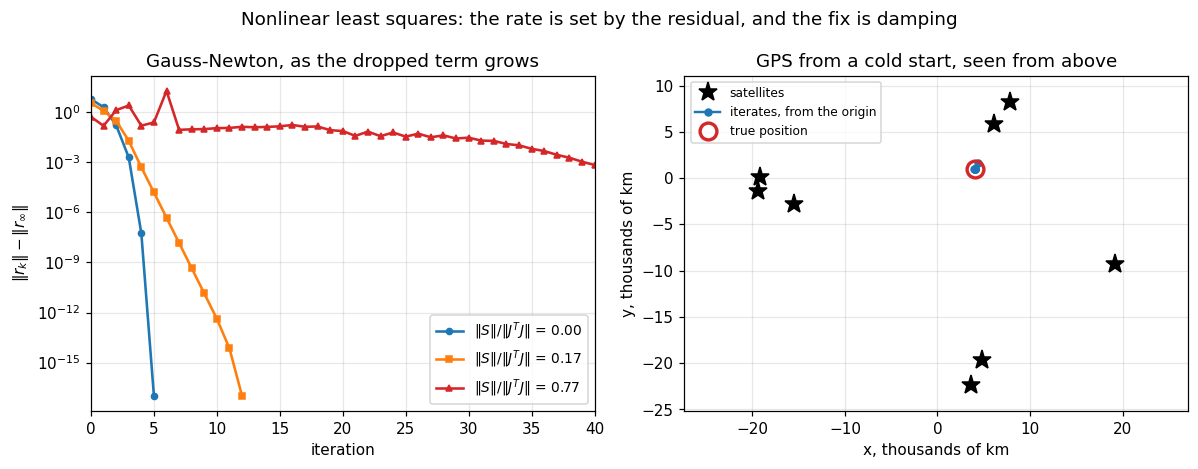

In [16]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4.3))

# left: convergence histories at three residual levels
for offset, style, colour in ((0.0, "o-", "C0"), (3.0, "s-", "C1"), (10.0, "^-", "C3")):
    q = nlls.large_residual_problem(40, offset)
    out = nlls.gauss_newton(q["residual"], q["jacobian"], [1.5, 1.1], max_iter=300)
    d = nlls.dropped_term(q["residual"], q["jacobian"], q["hessians"], out.x)
    errs = np.array([abs(v - out.residual_norm) for v in out.history])
    errs = np.maximum(errs, 1e-17)
    axL.semilogy(np.arange(errs.size), errs, style, color=colour, lw=1.7, ms=4,
                 label=f"$\\|S\\|/\\|J^TJ\\|$ = {d['ratio']:.2f}")
axL.set_xlabel("iteration")
axL.set_ylabel(r"$\|r_k\| - \|r_\infty\|$")
axL.set_title("Gauss-Newton, as the dropped term grows")
axL.legend(fontsize=9)
axL.set_xlim(0, 40)

# right: the GPS fit, seen from above
gen = np.random.default_rng(11)
angles = gen.uniform(0.0, 2.0 * np.pi, (8, 2))
sats = np.column_stack([
    orbit_radius * np.sin(angles[:, 0]) * np.cos(angles[:, 1]),
    orbit_radius * np.sin(angles[:, 0]) * np.sin(angles[:, 1]),
    orbit_radius * np.cos(angles[:, 0])])
gps = nlls.gps_problem(sats, receiver, clock_bias, noise=5.0, rng=np.random.default_rng(4))
path = []
x_iter = np.zeros(receiver.size + 1)      # position plus the clock bias
for _ in range(7):
    step = nlls.levenberg_marquardt(gps["residual"], gps["jacobian"], x_iter, max_iter=1)
    x_iter = step.x
    path.append(x_iter[:2].copy())
path = np.array(path) / 1e6

axR.plot(sats[:, 0] / 1e6, sats[:, 1] / 1e6, "k*", ms=13, label="satellites")
axR.plot(path[:, 0], path[:, 1], "C0.-", lw=1.6, ms=9, label="iterates, from the origin")
axR.plot(receiver[0] / 1e6, receiver[1] / 1e6, "C3o", ms=11, mfc="none", mew=2.2,
         label="true position")
axR.set_xlabel("x, thousands of km")
axR.set_ylabel("y, thousands of km")
axR.set_title("GPS from a cold start, seen from above")
axR.legend(fontsize=8, loc="upper left")
axR.set_aspect("equal", adjustable="datalim")

fig.suptitle("Nonlinear least squares: the rate is set by the residual, and the fix is damping",
             fontsize=12)
fig.tight_layout()
plt.show()

**The left panel is section 3 in one image.** Three curves on the same problem family: one falls
off a cliff (quadratic), one is a straight line on a log axis (linear), and one is nearly flat.
The only thing that changed is how much residual is left at the minimum.

---

## 10. Exercises

**Level 1, conceptual**

1.1 Gauss-Newton converged quadratically on one problem and linearly on another, using the same
code. What is different about the two problems, and how would you tell in advance?

1.2 Levenberg-Marquardt's damping makes it more reliable. Give a case where that reliability is
a disadvantage, and say what you would do about it.

1.3 The exact Hessian is available for the problems in this lesson, and using it gave worse
answers. Explain why, without using the word "expensive".

**Level 2, mathematical**

2.1 Derive $\nabla f = J^T\mathbf{r}$ and $\nabla^2 f = J^TJ + S$ from
$f = \tfrac12\|\mathbf{r}\|^2$, and identify precisely which term Gauss-Newton drops and why it
vanishes at a zero residual solution.

2.2 Show that the Gauss-Newton step is a descent direction whenever $J$ has full column rank,
and give an example with rank deficient $J$ where it is not defined.

2.3 Prove that the Levenberg-Marquardt step solves the trust region subproblem
$\min\|J\mathbf{p}+\mathbf{r}\|$ subject to $\|D^{1/2}\mathbf{p}\|\le\Delta$, with $\lambda$ the
Lagrange multiplier, and describe the correspondence between $\lambda$ and $\Delta$.

2.4 Derive the asymptotic convergence factor of Gauss-Newton in terms of
$\rho\big((J^TJ)^{-1}S\big)$ at the solution, and confirm it against the measured linear
factors in section 3.

2.5 Show that the GPS Jacobian's position columns are unit vectors from receiver to satellite,
and that its last column is all ones. Then show that the problem is singular when all satellites
lie on one plane through the receiver.

**Level 3, computational**

3.1 Implement a proper **trust region** method: choose the step by solving the constrained
subproblem exactly, and update $\Delta$ from the ratio of actual to predicted reduction. Compare
against the damping heuristic of this lesson on the hard problems.

3.2 Implement **variable projection** properly, with the Golub-Pereyra derivative of the reduced
function, and compare its basin of attraction against the full Gauss-Newton on a two exponential
fit.

3.3 Implement **robust nonlinear least squares** with a Huber or Tukey loss, and measure it
against plain nonlinear least squares on data containing outliers, as lesson 29 exercise 5.3 did
for the linear case.

**Level 4, experimental**

4.1 Map the basins of attraction of a two parameter fit: run from a grid of starting points and
colour each by which minimum it reaches. Do it for Gauss-Newton and Levenberg-Marquardt and
compare the pictures.

4.2 Measure how the number of iterations depends on $\|S\|/\|J^TJ\|$ across many problems, and
fit the relationship. Then check whether the fitted curve predicts a problem it was not fitted
to.

4.3 For the GPS problem, measure the position error against the satellite geometry over many
configurations, and fit it against $\kappa(J)$. Separate the horizontal and vertical components
and explain why they differ.

**Level 5, advanced**

5.1 **Why the residual and not the objective.** Gauss-Newton linearises $\mathbf{r}$; Newton
uses a quadratic model of $f$. Show that linearising $\mathbf{r}$ and then squaring is *not* the
same as taking the quadratic model of $f$, identify the difference as exactly $S$, and explain
which of the two is a better model near a zero residual solution.

5.2 **Errors in variables, nonlinearly.** Lesson 33 showed that ordinary least squares is biased
when the design matrix is noisy. State what the analogous statement is when the model is
nonlinear, work out what total least squares becomes, and measure the bias on the GPS problem
when the satellite positions are themselves uncertain.

5.3 **Separable and constrained together.** Many real fits have parameters that must stay
positive, or sum to one. Work out how to impose those constraints without destroying the least
squares structure, compare a change of variables against a projection against a penalty, and say
what each does to the conditioning.

## 11. Key takeaways

- **Nonlinear least squares is linear least squares repeated.** The Gauss-Newton step solves
  $\min\|J\mathbf{p}+\mathbf{r}\|$, so lessons 29 to 32 govern the inner solve entirely,
  including using QR rather than the normal equations.
- **The exact Hessian is $J^TJ + S$ with $S = \sum r_i\nabla^2 r_i$, and Gauss-Newton drops
  $S$.** That is the whole approximation, stated exactly.
- **$S$ is the residual times the curvature**, so the method is exact when the residual is zero.
  Measured: order **1.90** and 5 iterations on an exact fit.
- **The ratio $\|S\|/\|J^TJ\|$ predicts everything.** Measured as it grows 0.00, 0.05, 0.17,
  0.28: iteration counts 5, 8, 12, 16. The degradation is smooth and predictable.
- **At a ratio near 1 there is no convergence at all.** Measured at 0.99: 300 iterations achieve
  nothing, on the same problem that converges in 12 from a different start.
- **Levenberg-Marquardt damps the step**, solving $(J^TJ+\lambda D)\mathbf{p} = -J^T\mathbf{r}$
  as a **stacked** least squares problem whose condition number is better than $\kappa(J)$,
  never as normal equations.
- **$\lambda$ interpolates continuously between Gauss-Newton and steepest descent**, and it is
  raised when a step fails and lowered when one works, making it a running estimate of how far
  the linearisation can be trusted.
- **Measured, it took 4 times fewer iterations and found a better minimum** on the hard problem:
  20 against 79, and $\|r\| = 60.19$ against 65.84.
- **And it is sometimes worse.** Measured from a different start on an easier problem:
  Gauss-Newton reached $\|r\| = 5.99$ and Levenberg-Marquardt settled at 12.16, because damping
  kept it in the nearer, worse basin.
- **Keeping the exact Hessian is not simply better.** Newton took fewer iterations at every
  residual level and landed on a **worse** point every time, because $J^TJ+S$ can be indefinite
  while $J^TJ$ cannot.
- **That is the real argument for Gauss-Newton**: dropping $S$ makes the model Hessian positive
  semidefinite by construction, so every step goes downhill. Cheapness is the second reason,
  not the first.
- **GPS needs four satellites for three coordinates**, because the receiver clock is an unknown
  that enters every measurement identically. Measured from a cold start at the centre of the
  Earth: convergence in a handful of iterations, to within metres.
- **The accuracy is set by the geometry, not the ranging noise.** Measured with the noise held
  at 5 metres throughout, the position error tracks $\kappa(J)$ as the satellites are squeezed
  into a narrower cone. That is dilution of precision, and it is lesson 29's conditioning in a
  nonlinear disguise.
- **Variable projection eliminates the linear parameters**, turning a two parameter search into
  a one parameter scan that can simply be plotted.

## Where this goes next

**Part 5 ends here.** Lessons 29 to 34 built least squares from the normal equations through
orthogonalization, conditioning, rank and nonlinearity.

**Lesson 41** builds the SVD that lessons 32 and 33 used on credit, including the Eckart-Young
theorem behind total least squares, and **lesson 43** develops low rank approximation.

**Lesson 84** returns to optimization in general, where nonlinear least squares is the special
case with structure worth exploiting, and the trust region idea of exercise 3.1 is developed
properly.

**Lesson 92** uses everything here: training a model is nonlinear least squares with a very large
$m$ and $n$, and the reason it is done with gradient methods rather than Gauss-Newton is that
$J$ cannot be stored.

Solutions are in [`solutions/part05_least_squares_and_qr.md`](../solutions/part05_least_squares_and_qr.md).